## Regression Modelling

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

#Loadi ndependent features into a pandas dataframe
df = pd.DataFrame(housing.data, columns=housing.feature_names) 

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 

In [3]:
# Load Dependent Variable
df['MedHouseVal'] = housing.target

df['MedHouseVal'].head()


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

> **Column reference:**
> - `MedInc` — median income in block group (tens of thousands of $)
> - `HouseAge` — median house age in block group
> - `AveRooms` — average number of rooms per household
> - `AveBedrms` — average number of bedrooms per household
> - `Population` — block group population
> - `AveOccup` — average number of household members
> - `Latitude`, `Longitude` — block group location
> - `MedHouseVal` — **target**: median house value (in $100,000s)


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Find Correlation between MedInc and MedHouseVal.

<Axes: >

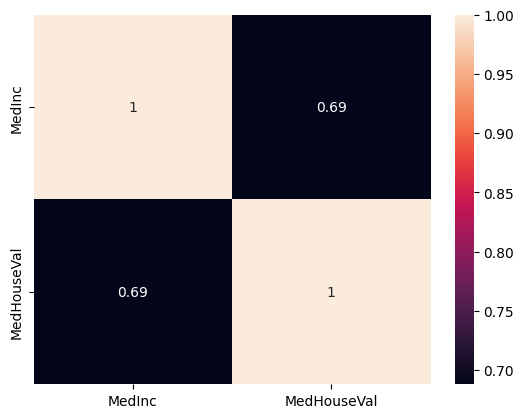

In [5]:

sns.heatmap(df[['MedInc','MedHouseVal']].corr(numeric_only=True),annot=True)

Print Heatmap to find correlation among all features

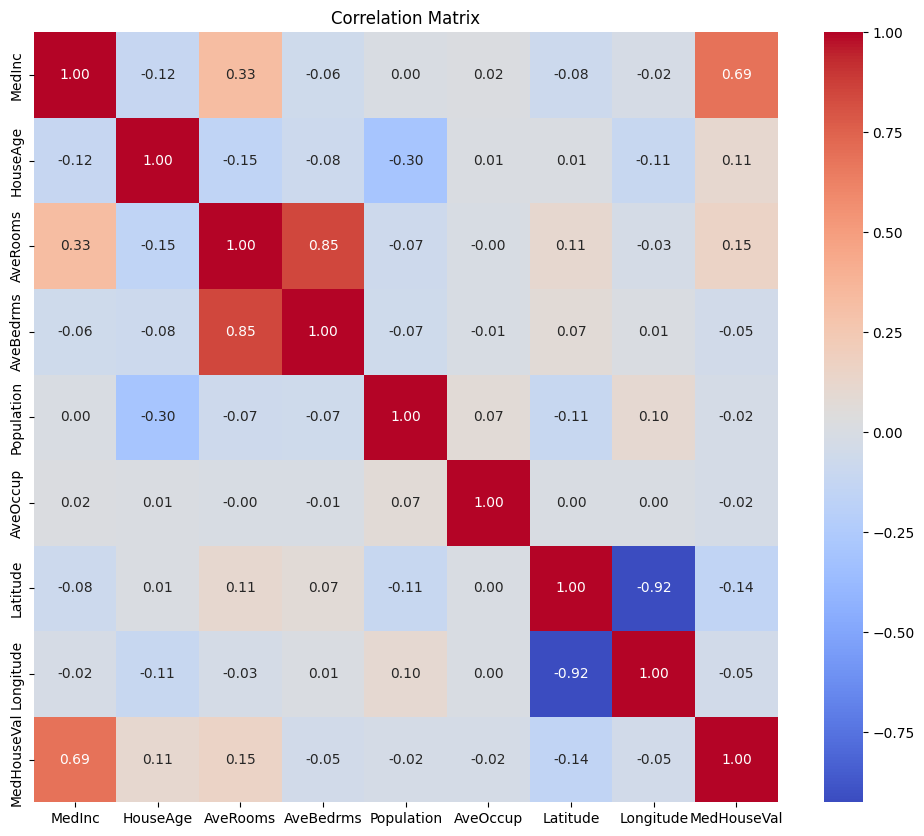

In [6]:
#Prepare a heatmap to justify the correlation between all the features in the dataset.
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


Create a scatter plot of `MedInc` (x-axis) vs `MedHouseVal` (y-axis). Based on visual inspection, does a linear relationship seem appropriate here? Why or why not?


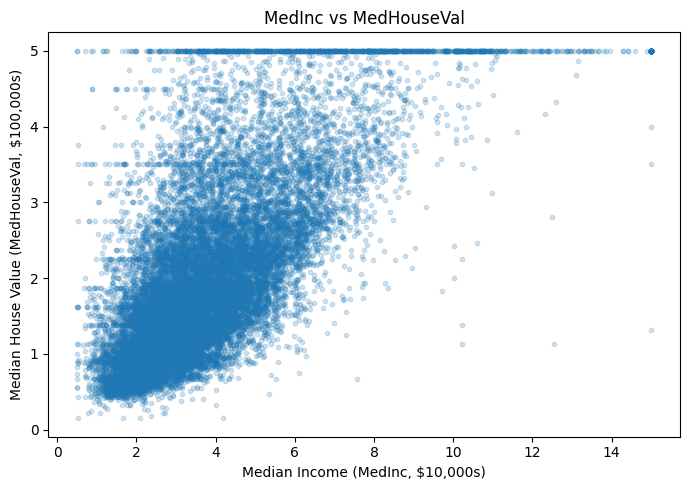

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(x=df['MedInc'],y=df['MedHouseVal'], alpha=0.2, s=10)
plt.xlabel('Median Income (MedInc, $10,000s)')
plt.ylabel('Median House Value (MedHouseVal, $100,000s)')
plt.title('MedInc vs MedHouseVal')
plt.tight_layout()
plt.show()



Add a best fit line using regplot

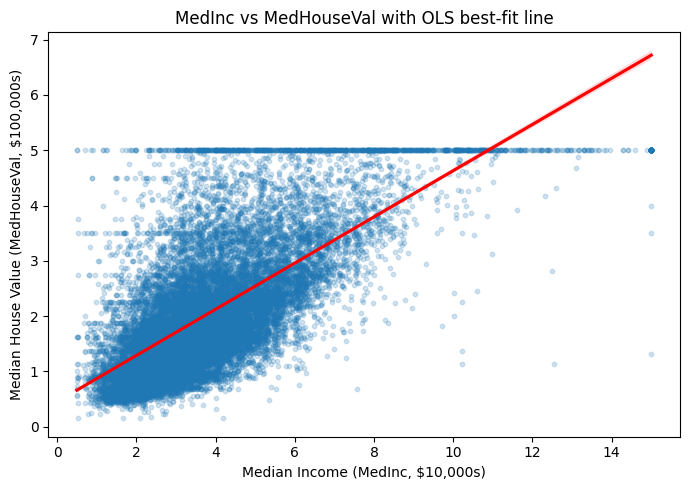

In [8]:
plt.figure(figsize=(7, 5))
sns.regplot(x='MedInc', y='MedHouseVal',data=df,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
plt.xlabel('Median Income (MedInc, $10,000s)')
plt.ylabel('Median House Value (MedHouseVal, $100,000s)')
plt.title('MedInc vs MedHouseVal with OLS best-fit line')
plt.tight_layout()
plt.show()

Using AveRooms as the predictor and MedHouseVal as the target, sketch (via sns.regplot) what you expect the best fit line to look like, and explain your reasoning before fitting any model.

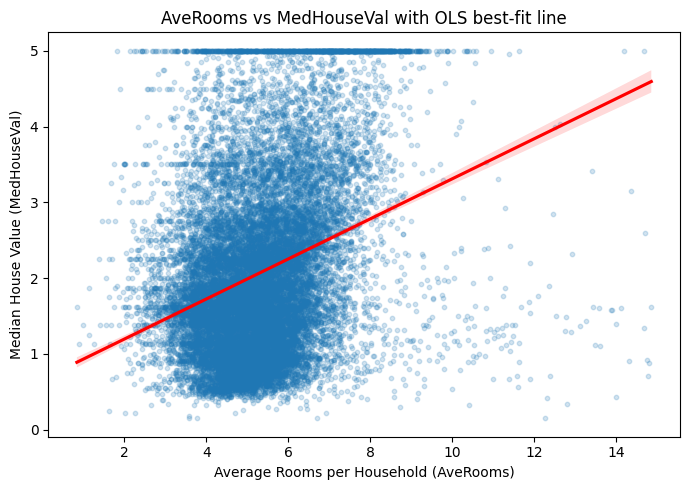

In [9]:
plot_df = df[df['AveRooms'] < 15]
plt.figure(figsize=(7, 5))
sns.regplot(x='AveRooms', y='MedHouseVal', data=plot_df,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
plt.xlabel('Average Rooms per Household (AveRooms)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('AveRooms vs MedHouseVal with OLS best-fit line')
plt.tight_layout()
plt.show()


What is a residual in linear regression? For a simple model predicting MedHouseVal from MedInc, define the residual for a single housing block in terms of actual vs. predicted median house value.

In [10]:
# Justification: demonstrate the residual formula on a couple of real rows
# using a quick trial line, so the definition isn't purely abstract.
beta0_demo, beta1_demo = 0.5, 0.4  # arbitrary trial coefficients, refined later
sample = df[['MedInc', 'MedHouseVal']].head(5).copy()
sample['predicted'] = beta0_demo + beta1_demo * sample['MedInc']
sample['residual'] = sample['MedHouseVal'] - sample['predicted']
print(sample)


   MedInc  MedHouseVal  predicted  residual
0  8.3252        4.526    3.83008   0.69592
1  8.3014        3.585    3.82056  -0.23556
2  7.2574        3.521    3.40296   0.11804
3  5.6431        3.413    2.75724   0.65576
4  3.8462        3.422    2.03848   1.38352


Fit OLS Method on Full Dataset

In [11]:
import statsmodels.api as sm

# Predictor and target
X = df[['MedInc']]
y = df['MedHouseVal']

# Add intercept
X = sm.add_constant(X)

# Fit OLS
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

# Beta coefficients
print("Intercept:", model.params['const'])
print("Slope:", model.params['MedInc'])

ModuleNotFoundError: No module named 'statsmodels'

Print Parameters:

In [ ]:
beta = model.params
print(beta)

Fit Linear Regression Model on Entire Dataset

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['MedInc']]
y = df['MedHouseVal']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

In [ ]:
a=4
b=3

while(){
    
}